# Level 3 - Task 4: Predictive Modeling

## Objective

The objective of this task is to build a machine learning model that predicts restaurant ratings using selected restaurant features.

### This task includes:

- Data preprocessing
- Feature encoding
- Train-test split
- Model training
- Model evaluation
- Feature importance analysis

### Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Step 1: Load Dataset

In [5]:
df = pd.read_csv("../Dataset.csv")

## Step 2: Select Features

The following features are used to predict restaurant ratings.

- Average Cost for two
- Price Range
- Votes
- Has Online Delivery
- Has Table Booking

In [13]:
data = df[[
    "Average Cost for two",
    "Price range",
    "Votes",
    "Has Online delivery",
    "Has Table booking",
    "Aggregate rating"
]]

## Step 3: Convert Categorical Variables

In [20]:
data.loc[:, "Has Online delivery"] = data["Has Online delivery"].map({
    "Yes": 1,
    "No": 0
})

data.loc[:, "Has Table booking"] = data["Has Table booking"].map({
    "Yes": 1,
    "No": 0
})

## Step 4: Define Features and Target

In [23]:
X = data.drop("Aggregate rating", axis=1)

y = data["Aggregate rating"]

## Step 5: Split Dataset

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 6: Train Random Forest Model

In [31]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Step 7: Make Predictions

In [34]:
predictions = model.predict(X_test)

## Step 8: Evaluate Model

In [37]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", round(mae,2))
print("Root Mean Squared Error :", round(rmse,2))
print("R² Score :", round(r2,2))

Mean Absolute Error : 0.25
Root Mean Squared Error : 0.38
R² Score : 0.94


## Step 9: Feature Importance

Determine which features contribute most to predicting restaurant ratings.

In [40]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Votes,0.975558
0,Average Cost for two,0.019256
1,Price range,0.005186
3,Has Online delivery,0.000000
4,Has Table booking,0.000000


## Step 10: Visualize Feature Importance

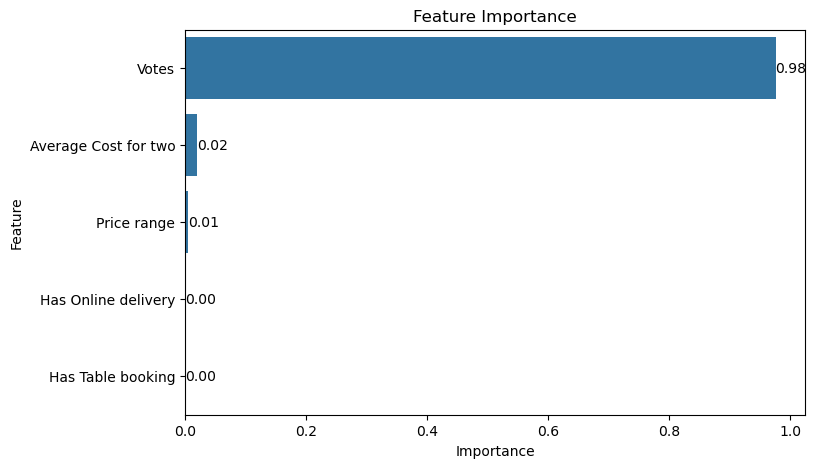

In [43]:
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Feature Importance")

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insight

- Customer votes are one of the strongest indicators of restaurant ratings.
- Restaurants offering table booking or online delivery may receive better customer engagement.
- Pricing also influences customer perception and ratings.
- Machine learning can help restaurant owners estimate customer satisfaction using operational features.

# Conclusion

## Key Findings

- A Random Forest Regression model was successfully built.
- The model predicts restaurant ratings using operational features.
- Feature importance analysis identified the most influential variables.
- This predictive model demonstrates how machine learning can support business decision-making in the restaurant industry.